# AutoEncoders

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import TensorDataset, DataLoader

def draw_circle(radius, center_x=0.5, center_y=0.5, size=28):
    # draw a circle using coordinates for the center, and the radius
    circle = plt.Circle((center_x, center_y), radius, color='k', fill=False)
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.add_patch(circle)
    ax.axis('off')
    buf = fig.canvas.print_to_buffer()
    plt.close()
    # converts matplotlib figure into PIL image, make it grayscale, and resize it
    return np.array(Image.frombuffer('RGBA', buf[1], buf[0]).convert('L').resize((int(size), int(size))))

def gen_circles(n, size=28):
    # generates random coordinates around (0.5, 0.5) as center points
    center_x = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    center_y = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    # generates random radius sizes between 0.03 and 0.47
    radius = np.random.uniform(0.03, 0.47, size=n).reshape(-1, 1)
    sizes = np.ones((n, 1))*size

    coords = np.concatenate([radius, center_x, center_y, sizes], axis=1)
    # generates circles using draw_circle function
    circles = np.apply_along_axis(func1d=lambda v: draw_circle(*v), axis=1, arr=coords)
    return circles, radius

np.random.seed(42)
# generates 1,000 circles
circles, radius = gen_circles(1000)

circles_ds = TensorDataset(torch.as_tensor(circles).unsqueeze(1).float()/255, torch.as_tensor(radius))
circles_dl = DataLoader(circles_ds, batch_size=32, shuffle=True, drop_last=True)

## Encoder

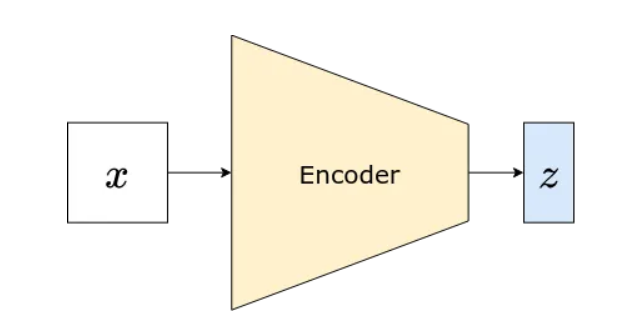

In [7]:
import torch.nn as nn

def set_seed(self, seed=42):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    np.random.seed(seed)

class Encoder(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()
        self.input_shape = input_shape
        self.z_size = z_size
        self.base_model = base_model

        # appends the "lin_latent" linear layer to map from "output_size"
        # given by the base model to desired size of the representation (z_size)
        output_size = self._get_output_size()
        self.lin_latent = nn.Linear(output_size, z_size)

    def _get_output_size(self):
        # builds a dummy batch containing one dummy tensor
        # full of zeroes with the same shape as the inputs
        device = next(self.base_model.parameters()).device.type
        dummy = torch.zeros(1, *self.input_shape, device=device)
        # sends the dummy batch through the base model to get
        # the output size produced by it
        size = self.base_model(dummy).size(1)
        return size

    def forward(self, x):
        # forwards the input through the base model and then the "lin_latent" layer
        # to get the representation (z)
        base_out = self.base_model(x)
        out = self.lin_latent(base_out)
        return out

set_seed(13)

# we defined our representation (z) as a vector of size one
z_size = 1
# our images are 1@28x28
input_shape = (1, 28, 28) # (C, H, W)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder = Encoder(input_shape, z_size, base_model)

In [8]:
encoder

Encoder(
  (base_model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=2048, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=2048, out_features=2048, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
  )
  (lin_latent): Linear(in_features=2048, out_features=1, bias=True)
)

Keeping base_model and lin_latent separate helps because:

- The base_model focuses on learning good feature representations.

- The lin_latent layer specializes in squeezing those features into a compact form the decoder can use.

In [ ]:
x, _ = circles_ds[7] # Image number 7
z = encoder(x)
z # vector of size one is called latent space

tensor([[-0.1209]], grad_fn=<AddmmBackward0>)

## Decoder

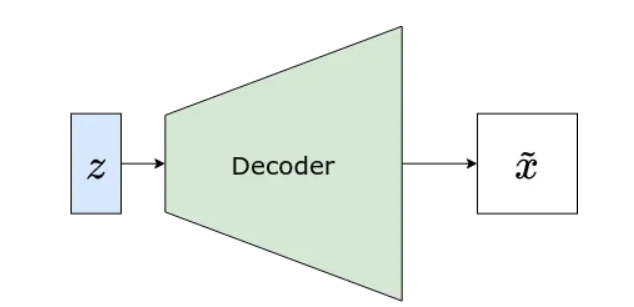

In [10]:
decoder = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

In [11]:
decoder

Sequential(
  (0): Linear(in_features=1, out_features=2048, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=2048, out_features=2048, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=2048, out_features=784, bias=True)
  (5): Unflatten(dim=1, unflattened_size=(1, 28, 28))
)

In [12]:
x_tilde = decoder(z)
x_tilde, x_tilde.shape

(tensor([[[[ 1.9079e-01, -4.3900e-02, -4.9170e-02,  5.2142e-02, -8.0119e-02,
            -1.6324e-01,  3.8319e-02,  6.2965e-02, -3.7442e-02, -3.6085e-02,
             2.2930e-02, -1.2089e-01,  2.0558e-01,  1.3671e-01,  1.4608e-03,
             1.1066e-02, -1.3429e-01, -3.7842e-02,  6.1736e-02, -3.0216e-02,
            -7.4171e-02, -1.6376e-02, -6.4663e-02, -1.5638e-01, -9.6260e-02,
             5.3312e-02,  6.6354e-02, -2.6916e-02],
           [ 1.8874e-01,  9.7503e-02, -1.3948e-01, -1.2955e-01, -1.2210e-02,
             5.6815e-02, -7.5753e-02,  5.3483e-02,  6.4153e-02, -1.6740e-01,
            -5.0190e-02,  6.2855e-02,  9.7707e-02, -2.2777e-02, -1.1442e-01,
             1.6079e-01, -1.4634e-01,  2.0068e-01, -2.7668e-02,  6.3487e-02,
            -9.6758e-02,  3.0803e-02, -7.0600e-02,  1.1162e-01,  8.6569e-02,
            -1.5205e-02,  1.9754e-01,  1.1691e-01],
           [-7.3312e-02,  9.0082e-02, -4.4267e-02,  1.1471e-01,  6.9005e-02,
             1.5235e-03, -4.2527e-02,  1.4255e-01

We can see negative values in the pixel of image which is supposed to be within [0,1] range, but never a negative value. SO we need to train by choose the loss function accordingly wrt task (MSE for our task). 

## AutoEncoder (AE)

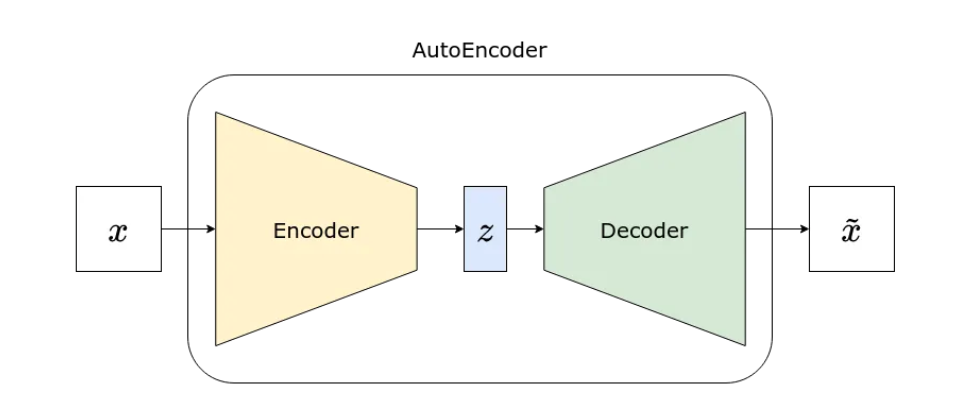

In [13]:
class AutoEncoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.enc = encoder
        self.dec = decoder

    def forward(self, x):
        # when encoder met decoder
        enc_out = self.enc(x)
        return self.dec(enc_out)

model_ae = AutoEncoder(encoder, decoder)

In [14]:
model_ae

AutoEncoder(
  (enc): Encoder(
    (base_model): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=2048, bias=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Linear(in_features=2048, out_features=2048, bias=True)
      (4): LeakyReLU(negative_slope=0.01)
    )
    (lin_latent): Linear(in_features=2048, out_features=1, bias=True)
  )
  (dec): Sequential(
    (0): Linear(in_features=1, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=2048, out_features=2048, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=2048, out_features=784, bias=True)
    (5): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)

### Model Training (AE)

In [15]:
set_seed(13)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_ae.to(device)
loss_fn = nn.MSELoss()
optim = torch.optim.Adam(model_ae.parameters(), 0.0003)

num_epochs = 10

train_losses = []

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_ae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_ae(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, x)
        # Step 3 - Computes gradients
        loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()

        batch_losses.append(np.array([loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}')

Epoch 001 | Loss >> 0.1388
Epoch 002 | Loss >> 0.0062
Epoch 003 | Loss >> 0.0049
Epoch 004 | Loss >> 0.0048
Epoch 005 | Loss >> 0.0048
Epoch 006 | Loss >> 0.0048
Epoch 007 | Loss >> 0.0048
Epoch 008 | Loss >> 0.0048
Epoch 009 | Loss >> 0.0047
Epoch 010 | Loss >> 0.0046


### Example of Reconstruction

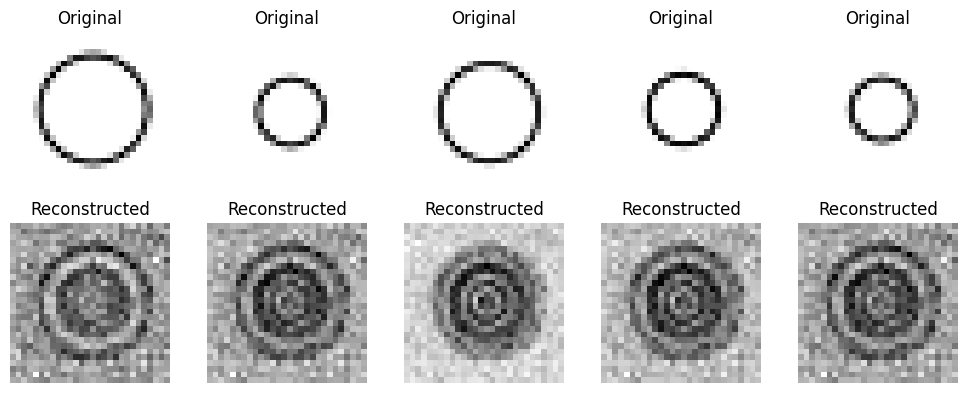

In [16]:
# Set model to eval mode
model_ae.eval()

# Take a batch from the dataloader
x_batch, _ = next(iter(circles_dl))
x_batch = x_batch.to(device)

# Get reconstructed output
with torch.no_grad():
    x_recon = model_ae(x_batch)

# Pick how many examples to show
n = 5
fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))

for i in range(n):
    # Original image
    axes[0, i].imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    # Reconstructed image
    axes[1, i].imshow(x_recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


# Variational AutoEncoders

## Variational AutoEncoder (VAE)

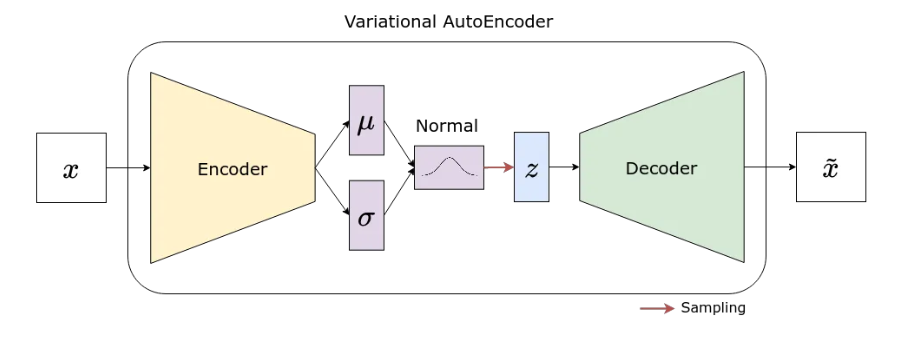

In the traditional autoencoder, the latent space is not continuous, that is, there is “empty” latent space so in VAE instead of producing points in the latent space, it produces distributions in the latent space

```EncoderVar(
  (base_model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=2048, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=2048, out_features=2048, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
  )
  (lin_mu): Linear(in_features=2048, out_features=1, bias=True)
  (lin_var): Linear(in_features=2048, out_features=1, bias=True)
)```

In [17]:
def forward(self, x):
    base_out = self.base_model(x)

    self.mu = self.lin_mu(base_out)
    self.log_var = self.lin_var(base_out)
    std = torch.exp(self.log_var/2)

    eps = torch.randn_like(self.mu)
    z = self.mu + eps * std
    return z

### Reparametrization Trick
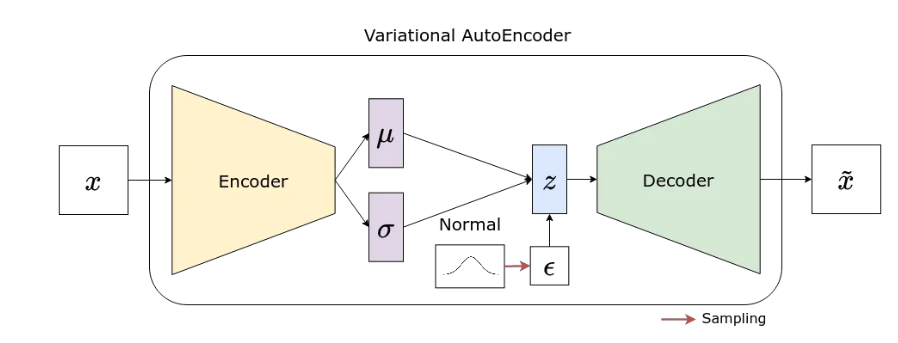

### Why isn't gradient-based learning possible without the reparameterization trick?

When training a Variational Autoencoder (VAE), the encoder outputs a distribution — usually defined by a **mean** ($\mu$) and **standard deviation** ($\sigma$). To get a latent vector `z`, we sample:

$$
z \sim \mathcal{N}(\mu, \sigma^2)
$$

However, **sampling is a non-differentiable operation**, which means we can't compute gradients through it. This blocks backpropagation, so the model can't learn how to update $\mu$ and $\sigma$ during training.

---

### Reparameterization Trick

To solve this, we re-write the sampling process as:

$$
z = \mu + \sigma \cdot \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, 1)
$$

Now, the randomness is moved to $\epsilon$, which is independent of the model parameters. This makes the entire operation **differentiable**, so we can use gradient-based optimization to train the model end-to-end.

---

**In short:**  
- Without reparameterization, we can't backpropagate through the sampling step.  
- With it, we can train the VAE using standard gradient descent.

In [18]:
# from torch.distributions.normal.Normal

def sample(self, sample_shape=torch.Size()):
    shape = self._extended_shape(sample_shape)
    with torch.no_grad():
        return torch.normal(self.loc.expand(shape),
                            self.scale.expand(shape))

def rsample(self, sample_shape=torch.Size()):
    shape = self._extended_shape(sample_shape)
    eps = _standard_normal(shape,
                           dtype=self.loc.dtype,
                           device=self.loc.device)
    return self.loc + eps * self.scale

In [19]:
class EncoderVar(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()
        self.z_size = z_size
        self.input_shape = input_shape
        self.base_model = base_model
        output_size = self.get_output_size()
        self.lin_mu = nn.Linear(output_size, z_size)
        self.lin_var = nn.Linear(output_size, z_size)

    def get_output_size(self):
        device = next(self.base_model.parameters()).device.type
        size = self.base_model(torch.zeros(1, *self.input_shape, device=device)).size(1)
        return size

    def kl_loss(self):
        kl_loss = -0.5*(1 + self.log_var - self.mu**2 - torch.exp(self.log_var))
        return kl_loss

    def forward(self, x):
        # the base model, same as the traditional AE
        base_out = self.base_model(x)

        # now the encoder produces means (mu) using the lin_mu output layer
        # and log variances (log_var) using the lin_var output layer
        # we compute the standard deviation (std) from the log variance
        self.mu = self.lin_mu(base_out)
        self.log_var = self.lin_var(base_out)
        std = torch.exp(self.log_var/2)

        # that's the internal random input (epsilon)
        eps = torch.randn_like(self.mu)
        # and that's the z vector
        z = self.mu + eps * std

        return z

In [20]:
set_seed(13)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder_var = EncoderVar(input_shape, z_size, base_model)

decoder_var = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

model_vae = AutoEncoder(encoder_var, decoder_var)

In [21]:
x, y = next(iter(circles_dl))
zs = encoder_var(x)
reconstructed = decoder_var(zs)

In [22]:
loss_fn_raw = nn.MSELoss(reduction='none')
raw_mse = loss_fn_raw(reconstructed, x)
raw_mse.shape

torch.Size([32, 1, 28, 28])

In [23]:
raw_mse.sum(), nn.MSELoss(reduction='sum')(reconstructed, x)

(tensor(24377.3906, grad_fn=<SumBackward0>),
 tensor(24377.3906, grad_fn=<MseLossBackward0>))

In [24]:
sum_over_pixels = raw_mse.sum(dim=[1, 2, 3])
sum_over_pixels.mean()

tensor(761.7935, grad_fn=<MeanBackward0>)

In [25]:
raw_kl = encoder_var.kl_loss()
raw_kl.shape

torch.Size([32, 1])

In [26]:
for raw, d in zip([raw_mse, raw_kl], [[1, 2, 3], 1]):
    print(f'{raw.mean(dim=d).mean(dim=0).item():.4f}, {raw.mean(dim=d).sum(dim=0).item():.4f}, '
          f'{raw.sum(dim=d).mean(dim=0).item():.4f}, {raw.sum(dim=d).sum(dim=0).item():.4f}')

0.9717, 31.0936, 761.7935, 24377.3926
0.0062, 0.1998, 0.0062, 0.1998


### Model Training (VAE)

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_vae.to(device)
loss_fn = nn.MSELoss(reduction='none')
optim = torch.optim.Adam(model_vae.parameters(), 0.0003)

num_epochs = 30

train_losses = []

reconstruction_loss_factor = 1

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_vae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_vae(x)

        # Step 2 - Computes the loss
        # reduce (sum) over pixels (dim=[1, 2, 3])
        # and then reduce (sum) over batch (dim=0)
        loss = loss_fn(yhat, x).sum(dim=[1, 2, 3]).sum(dim=0)
        # reduce (sum) over z (dim=1)
        # and then reduce (sum) over batch (dim=0)
        kl_loss = model_vae.enc.kl_loss().sum(dim=1).sum(dim=0)
        # we're adding the KL loss to the original MSE loss
        total_loss = reconstruction_loss_factor * loss + kl_loss

        # Step 3 - Computes gradients
        total_loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()

        batch_losses.append(np.array([total_loss.data.item(), loss.data.item(), kl_loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}/{train_losses[-1][1]:.4f}/{train_losses[-1][2]:.4f}')

Epoch 001 | Loss >> 4486.7130/4429.5525/57.1605
Epoch 002 | Loss >> 232.6676/168.6818/63.9858
Epoch 003 | Loss >> 177.8200/132.0482/45.7718
Epoch 004 | Loss >> 157.6563/129.3827/28.2736
Epoch 005 | Loss >> 150.1484/128.5988/21.5496
Epoch 006 | Loss >> 138.2835/126.6773/11.6062
Epoch 007 | Loss >> 130.6601/126.4626/4.1975
Epoch 008 | Loss >> 129.8200/126.6863/3.1337
Epoch 009 | Loss >> 128.0803/126.8280/1.2524
Epoch 010 | Loss >> 125.1085/124.5564/0.5521
Epoch 011 | Loss >> 127.6985/127.0570/0.6414
Epoch 012 | Loss >> 126.7858/126.0955/0.6903
Epoch 013 | Loss >> 124.3730/124.1855/0.1876
Epoch 014 | Loss >> 126.3395/125.8691/0.4704
Epoch 015 | Loss >> 125.8635/125.1980/0.6655
Epoch 016 | Loss >> 126.6485/126.0803/0.5682
Epoch 017 | Loss >> 126.3662/126.1120/0.2542
Epoch 018 | Loss >> 126.2584/125.7842/0.4742
Epoch 019 | Loss >> 127.3813/126.9991/0.3823
Epoch 020 | Loss >> 126.6893/126.1542/0.5351
Epoch 021 | Loss >> 126.4932/126.0360/0.4572
Epoch 022 | Loss >> 128.1486/127.7886/0.3600
Ep

Total Loss (First value)/Reconstruction Loss (Second value)/KL Loss (Third value)

- Total Loss (First value): Complete loss function combining both reconstruction and KL divergence

- Reconstruction Loss (Second value): Measures how well the VAE reconstructs the input image

- KL Loss (Third value) (Kullback-Leibler divergence loss): Measures how close the encoder's distribution is to a standard normal distribution

### Reconstruction (VAE)

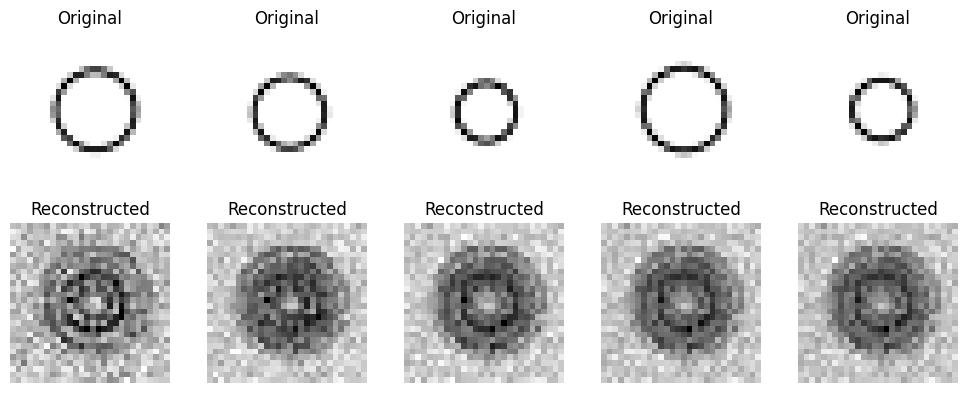

In [29]:
# Set VAE model to evaluation mode
model_vae.eval()

# Take a batch from the dataloader
x_batch, _ = next(iter(circles_dl))
x_batch = x_batch.to(device)

# Get reconstruction from VAE
with torch.no_grad():
    x_recon = model_vae(x_batch)

# Number of images to show
n = 5
fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))

for i in range(n):
    # Top row: original images
    axes[0, i].imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    # Bottom row: reconstructed images
    axes[1, i].imshow(x_recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Applications of Autoencoders and VAEs in Natural Language Processing

Autoencoders and Variational Autoencoders have found numerous applications in Natural Language Processing (NLP). Here are some key use cases:

## 1. Text Generation and Language Modeling

- **Sentence Generation**: VAEs can generate new, meaningful sentences by sampling from the learned latent space
- **Text Style Transfer**: Converting text from one style to another (e.g., formal to informal)
- **Paraphrase Generation**: Creating different versions of the same sentence while preserving meaning

VAEs are particularly useful here because they create a continuous latent space, allowing for smooth interpolation between different text styles or meanings.

## 2. Document Representation and Topic Modeling

- **Document Embeddings**: Creating compact, meaningful representations of documents
- **Topic Discovery**: Learning latent topics in document collections
- **Document Clustering**: Grouping similar documents based on their latent representations

Autoencoders can compress documents into dense vectors while preserving semantic meaning, making them valuable for document analysis tasks.

## 3. Text Summarization and Information Extraction

- **Abstractive Summarization**: Generating concise summaries by learning to compress and reconstruct text
- **Key Information Extraction**: Identifying and extracting important information from documents
- **Sentence Compression**: Reducing sentence length while maintaining core meaning

## 4. Machine Translation and Cross-lingual Applications

- **Neural Machine Translation**: Using sequence-to-sequence autoencoders for translation
- **Cross-lingual Document Alignment**: Matching documents across languages
- **Language-agnostic Representations**: Creating embeddings that work across multiple languages

The encoder-decoder architecture is fundamental to modern neural machine translation systems.

## 5. Text Denoising and Error Correction

- **Spelling Correction**: Learning to reconstruct correct spellings from noisy input
- **Grammar Correction**: Fixing grammatical errors in text
- **Text Normalization**: Standardizing text format and style

Autoencoders can learn to map noisy or incorrect text to its clean version, making them valuable for text preprocessing and correction tasks.

## 6. Advantages in NLP Applications

1. **Dimensionality Reduction**: Compress high-dimensional text data into meaningful lower-dimensional representations
2. **Feature Learning**: Automatically learn relevant features without manual engineering
3. **Generative Capabilities**: Create new text samples with desired properties
4. **Unsupervised Learning**: Learn from unlabeled text data, which is abundant
5. **Regularization**: VAEs provide natural regularization through the KL divergence term

These properties make autoencoders and VAEs powerful tools in modern NLP applications.